In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('water_data.csv')
data.head()

,numberofdeath,mothersageatfirstbirth,birthorder,childsex,childtwin,region,Residence,wealthindex,Education,toiletfacility,watersource,childreneverborn,breastfeeding,maritalstatus
0,1,22,6,1,1,1,3,2,1,2,1,6,1,1
1,1,22,5,1,1,1,3,2,1,2,1,6,1,1
2,1,22,4,1,1,1,3,2,1,2,1,6,1,1
3,1,22,3,2,1,1,3,2,1,2,1,6,1,1
4,1,22,2,1,1,1,3,2,1,2,1,6,1,1


In [3]:
x = data.drop(columns=['watersource'])
y = data['watersource']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

print("x_train shape: {}".format(x_train.shape))
print("x_test shape: {}".format(x_test.shape))

print("y_train shape: {}".format(y_train.shape))
print("y_test shape: {}".format(y_test.shape))

x_train shape: (3228, 13)
x_test shape: (1384, 13)
y_train shape: (3228,)
y_test shape: (1384,)


In [4]:
knn = KNeighborsClassifier(n_neighbors=7)
# train the model 
knn.fit(x_train, y_train)
# predict the outcome using test data
knn_predictions = knn.predict(x_test)

# evaluate the model by comparing the predicted outcome with the test outcome
Evaluation_results = accuracy_score(y_test, knn_predictions)

print("Accuracy=")
print(Evaluation_results)

Accuracy=
0.7391618497109826


In [5]:
knn_result = permutation_importance(knn, x, y, n_repeats=10)
importance_knn = knn_result.importances_mean

importance_knn = pd.DataFrame({'Feature': x.columns, 'Importance': importance_knn})

# Sort by importance and visualize (optional)
importance_knn = importance_knn.sort_values(by='Importance', ascending=False)
print(importance_knn.head(10).to_markdown(index=False, numalign="left", stralign="left"))

| Feature                | Importance   |
|:-----------------------|:-------------|
| mothersageatfirstbirth | 0.194731     |
| childreneverborn       | 0.178252     |
| region                 | 0.101605     |
| wealthindex            | 0.0998265    |
| numberofdeath          | 0.0378578    |
| Residence              | 0.0261275    |
| birthorder             | 0.01817      |
| Education              | 0.0139202    |
| maritalstatus          | 0.0135733    |
| breastfeeding          | 0.00936687   |


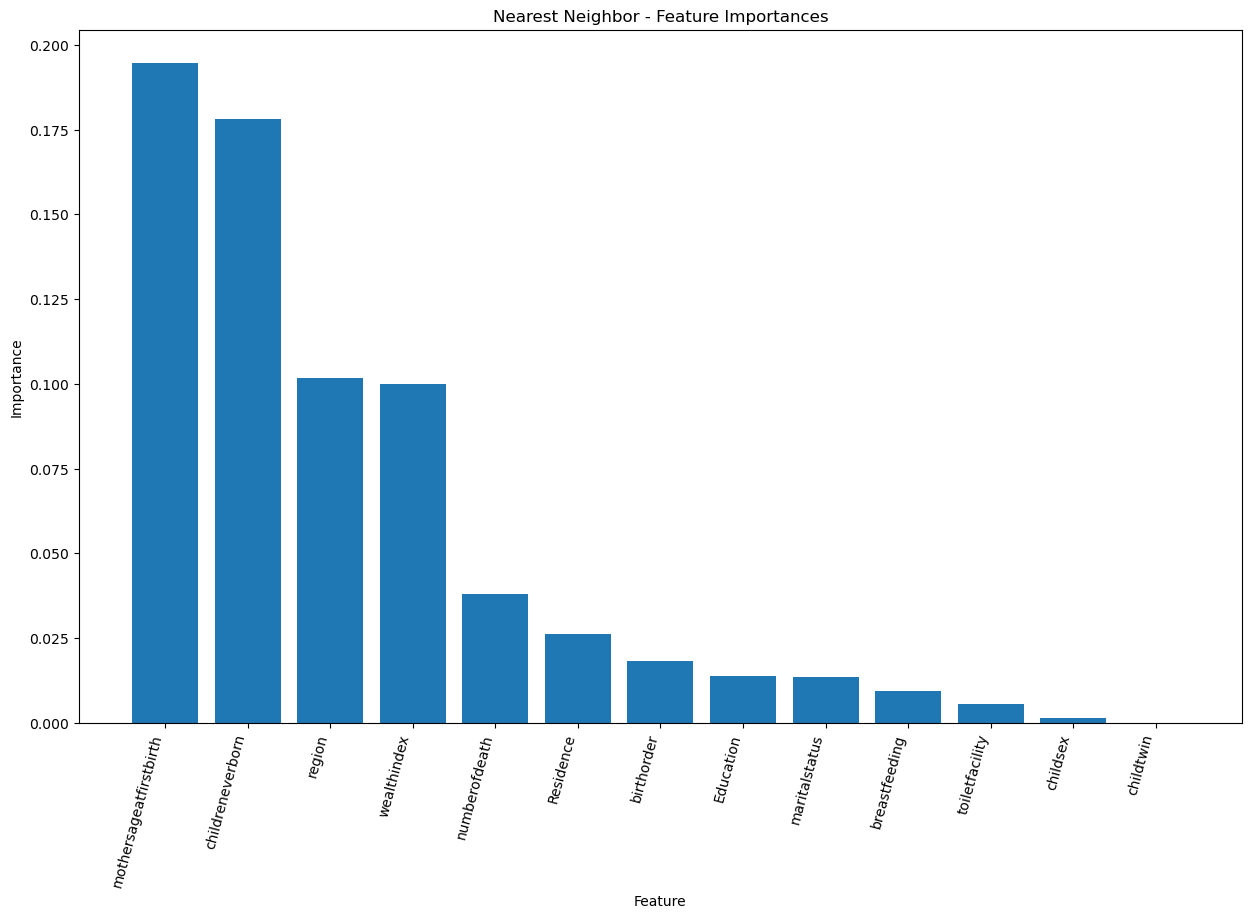

In [6]:
# Plotting feature importances
plt.figure(figsize=(15, 9))  # Adjust the size as needed
plt.bar(importance_knn['Feature'], importance_knn['Importance'])
plt.title("Nearest Neighbor - Feature Importances")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=75, ha="right")  # Rotate x-axis labels for readability
plt.show()  # Display the plot

In [12]:
# Make predictions on the test set
y_pred = knn.predict(x_test)

# 1. Predict Probabilities
y_proba = knn.predict_proba(x_test)[:, 1] # Probabilities for the positive class

# Calculate and print evaluation metrics
accuracy_knn = accuracy_score(y_test, y_pred)
precision_knn = precision_score(y_test, y_pred, average='weighted')
recall_knn = recall_score(y_test, y_pred, average='weighted')
f1_knn = f1_score(y_test, y_pred, average='weighted')
auc_knn = roc_auc_score(y_test, y_proba)

print("K-Nearest Neighbor ")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1-Score: {f1_knn:.4f}")
print(f"ROC AUC: {auc_knn:.4f}")

K-Nearest Neighbor 
Accuracy: 0.7392
Precision: 0.7397
Recall: 0.7392
F1-Score: 0.7390
ROC AUC: 0.8217


| Feature                | Importance   |
|:-----------------------|:-------------|
| numberofdeath          | 0.208895     |
| Residence              | 0.177202     |
| region                 | 0.169136     |
| Education              | 0.119089     |
| maritalstatus          | 0.11035      |
| childsex               | 0.0255627    |
| wealthindex            | 0.00425112   |
| birthorder             | 0.00172815   |
| mothersageatfirstbirth | -0.0119006   |
| childreneverborn       | -0.0281189   |


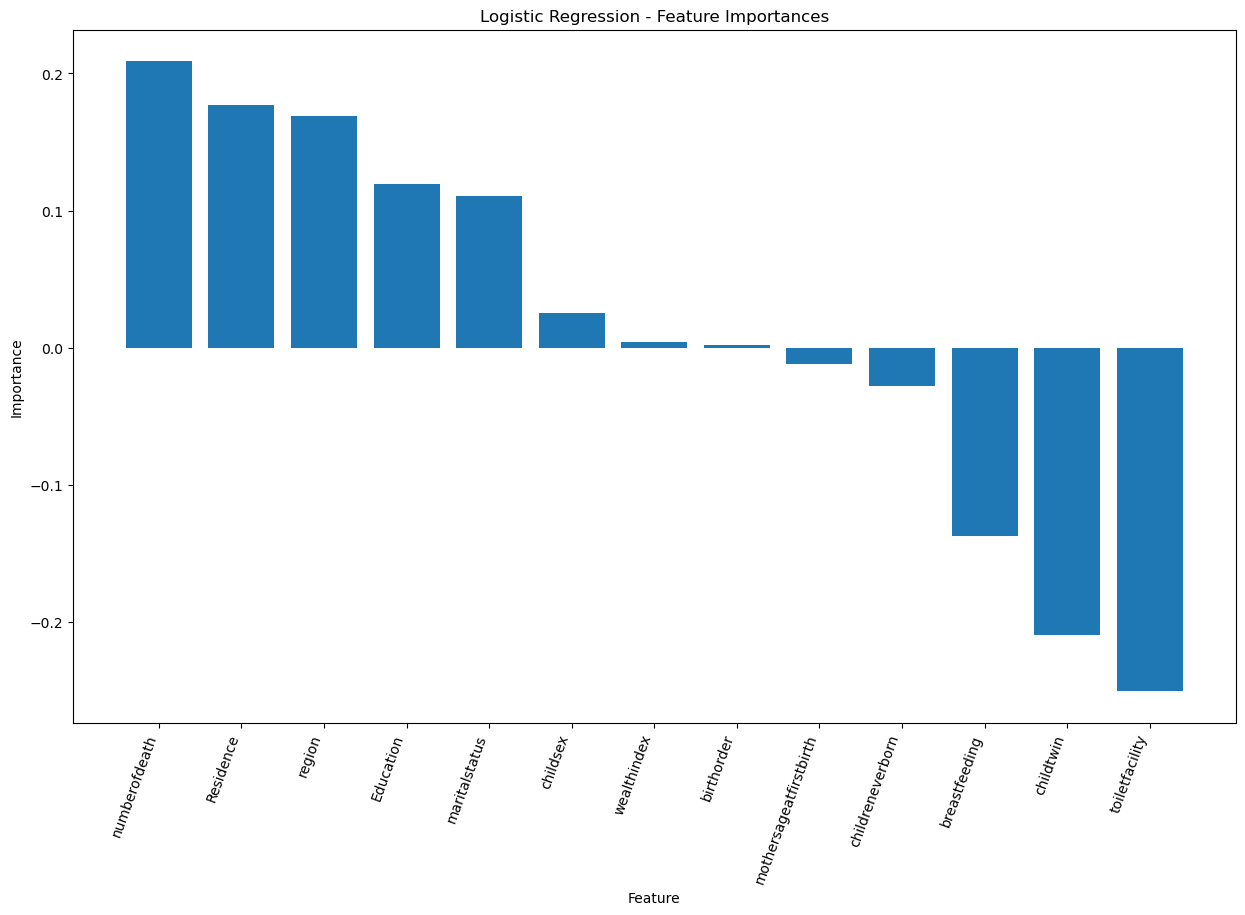

In [13]:
# a. Logistic Regression
LogReg = LogisticRegression(max_iter=1000)
LogReg.fit(x_train, y_train)
importances = LogReg.coef_[0]

importance_lr = pd.DataFrame({'Feature': x.columns, 'Importance': importances})

# Sort by importance and visualize (optional)
importance_lr = importance_lr.sort_values(by='Importance', ascending=False)
print(importance_lr.head(10).to_markdown(index=False, numalign="left", stralign="left"))
imp = importance_lr.head(10).to_markdown(index=False, numalign="left", stralign="left")

# Make predictions on the test set
y_pred = LogReg.predict(x_test)

# 1. Predict Probabilities
y_proba = LogReg.predict_proba(x_test)[:, 1] # Probabilities for the positive class

# Calculate and print evaluation metrics
accuracy_lr = accuracy_score(y_test, y_pred)
precision_lr = precision_score(y_test, y_pred, average='weighted')
recall_lr = recall_score(y_test, y_pred, average='weighted')
f1_lr = f1_score(y_test, y_pred, average='weighted')
auc_lr = roc_auc_score(y_test, y_proba)
# plotting faeture importance 
plt.figure(figsize=(15, 9))  # Adjust the size as needed
plt.bar(importance_lr['Feature'], importance_lr['Importance'])
plt.title('Logistic Regression - Feature Importances')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=70, ha='right')  # Rotate x-axis labels for readability
plt.savefig('logistic_regression_feature_importance.png')
plt.show()  # Display the plot



| Feature                | Importance   |
|:-----------------------|:-------------|
| mothersageatfirstbirth | 0.208496     |
| childreneverborn       | 0.179884     |
| wealthindex            | 0.126702     |
| region                 | 0.116339     |
| numberofdeath          | 0.0919336    |
| Residence              | 0.0885772    |
| Education              | 0.0546706    |
| maritalstatus          | 0.0438645    |
| breastfeeding          | 0.0432447    |
| toiletfacility         | 0.0413708    |
Decision Tree
Accuracy: 0.9848
Precision: 0.9849
Recall: 0.9848
F1-Score: 0.9848
ROC AUC: 0.9847


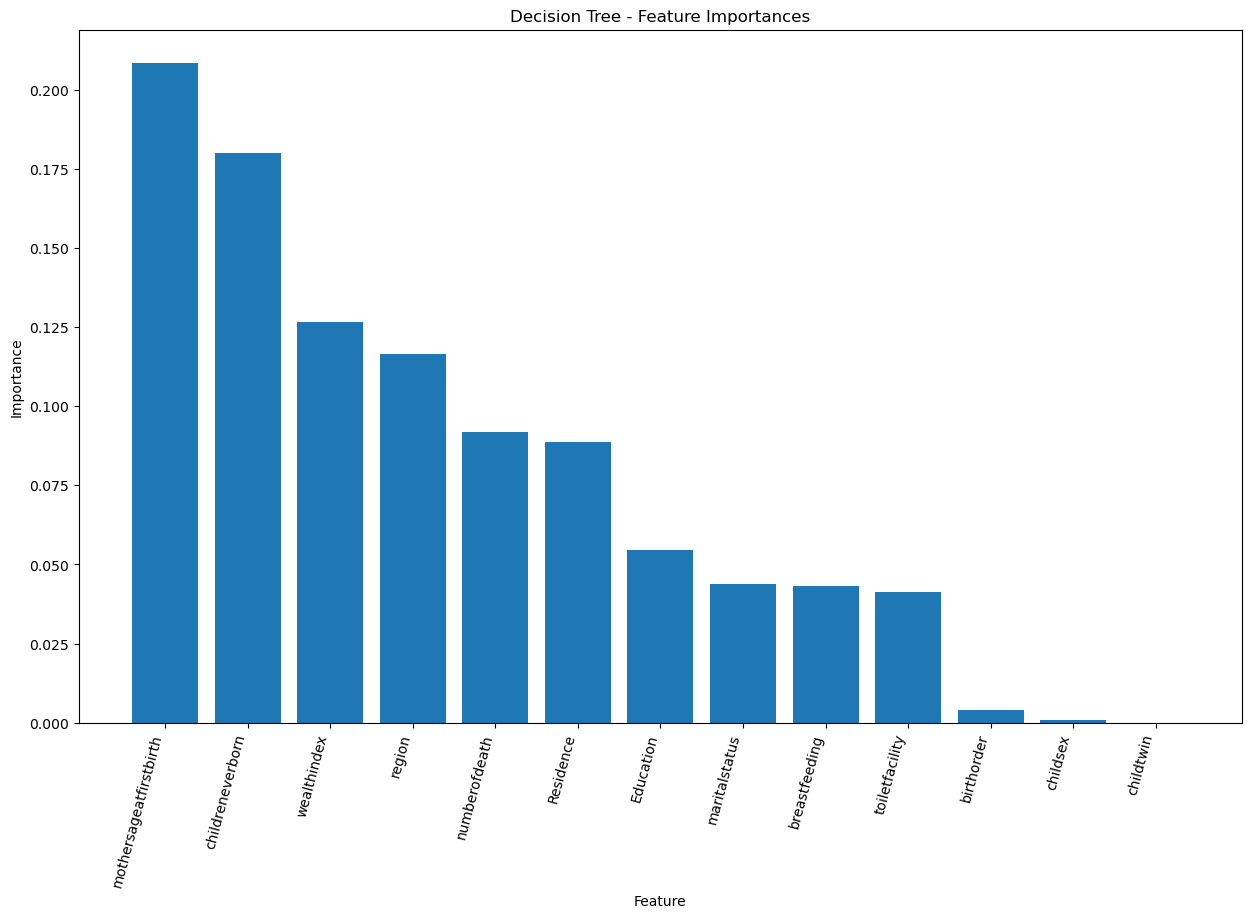

In [23]:
# b. DT Model
Dt_model = DecisionTreeClassifier()

# Training the model
Dt_model.fit(x_train, y_train)

# Extracting the key factors
importance_dt = Dt_model.feature_importances_

# Put the extracted key factors in a table
importance_dt = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importance_dt
})

# Sort by importance and visualize (optional)
importance_dt = importance_dt.sort_values(by='Importance', ascending=False)
print(importance_dt.head(10).to_markdown(index=False, numalign='left', stralign='left'))

# Make predictions on the test set
y_pred = Dt_model.predict(x_test)

# 1. Predict Probabilities
y_proba = Dt_model.predict_proba(x_test)[:, 1]  # Probabilities for the positive class

# Calculate and print evaluation metrics
accuracy_dt = accuracy_score(y_test, y_pred)
precision_dt = precision_score(y_test, y_pred, average='weighted')
recall_dt = recall_score(y_test, y_pred, average='weighted')
f1_dt = f1_score(y_test, y_pred, average='weighted')
auc_dt = roc_auc_score(y_test, y_proba)

print("Decision Tree")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")
print(f'ROC AUC: {auc_dt:.4f}')
# Plotting feature importances
plt.figure(figsize=(15, 9))  # Adjust the size as needed
plt.bar(importance_dt['Feature'], importance_dt['Importance'])
plt.title("Decision Tree - Feature Importances")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=75, ha="right")  # Rotate x-axis labels for readability
plt.show()  # Display the plot

| Feature                | Importance   |
|:-----------------------|:-------------|
| mothersageatfirstbirth | 0.219511     |
| childreneverborn       | 0.180884     |
| region                 | 0.133226     |
| wealthindex            | 0.100355     |
| numberofdeath          | 0.0870749    |
| birthorder             | 0.0615141    |
| Residence              | 0.0566919    |
| breastfeeding          | 0.0404735    |
| Education              | 0.0370974    |
| toiletfacility         | 0.027927     |
Random Forest
Accuracy: 0.9682
Precision: 0.9683
Recall: 0.9682
F1-Score: 0.9682
ROC AUC: 0.9968


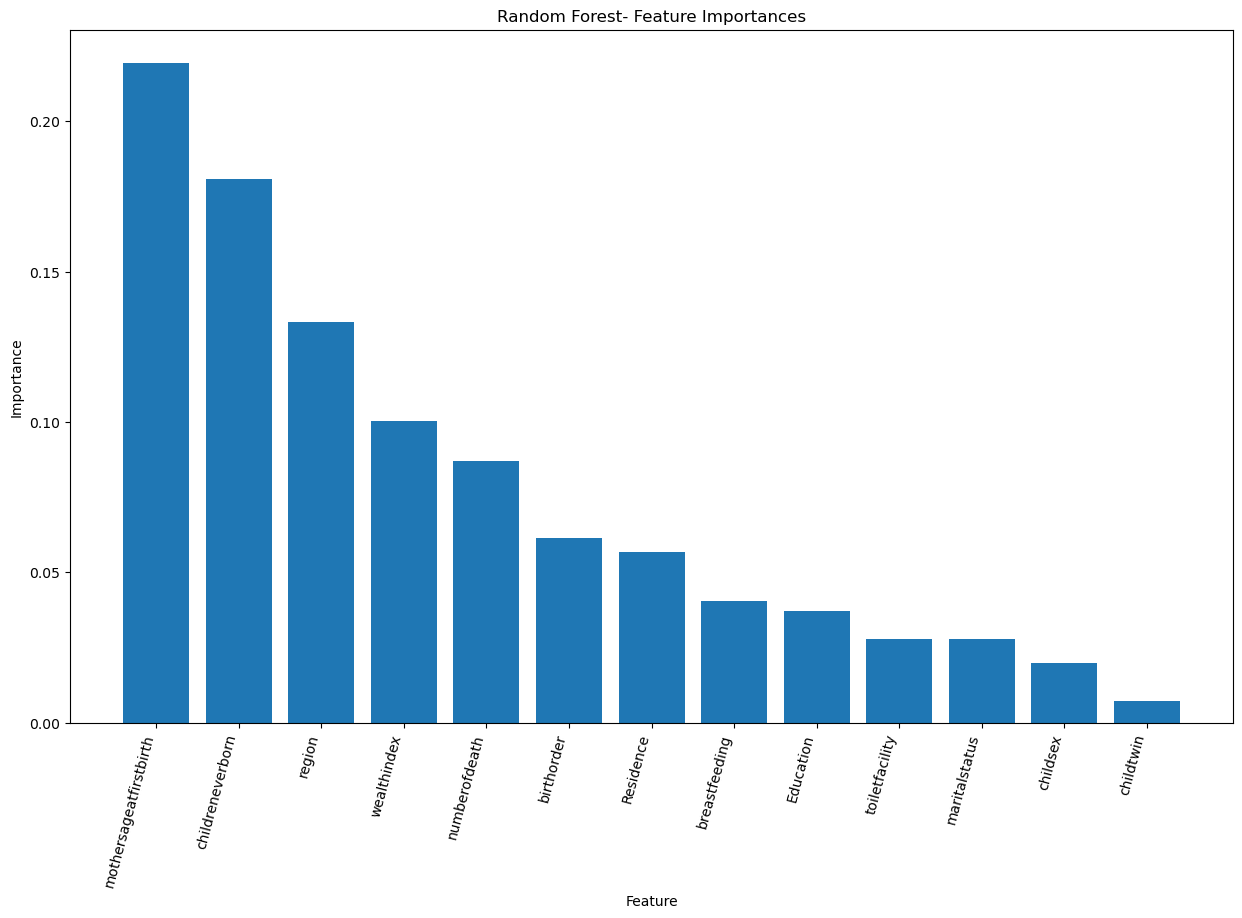

In [24]:
# c. RandomForestClassifier()
Rf_model = RandomForestClassifier()
Rf_model.fit(x_train, y_train)

importance_rf = Rf_model.feature_importances_
importance_rf = pd.DataFrame({'Feature': x.columns, 'Importance': importance_rf})

# Sort by importance and visualize (optional)
importance_rf = importance_rf.sort_values(by='Importance', ascending=False)
print(importance_rf.head(10).to_markdown(index=False, numalign="left", stralign="left"))

# Make predictions on the test set
y_pred = Rf_model.predict(x_test)

# 1. Predict Probabilities
y_proba = Rf_model.predict_proba(x_test)[:, 1] # Probabilities for the positive class

# Calculate and print evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred)
precision_rf = precision_score(y_test, y_pred, average='weighted')
recall_rf = recall_score(y_test, y_pred, average='weighted')
f1_rf = f1_score(y_test, y_pred, average='weighted')
auc_rf = roc_auc_score(y_test, y_proba)

print("Random Forest")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f'ROC AUC: {auc_rf:.4f}')

# Plotting feature importances
plt.figure(figsize=(15,9))  # Adjust the size as needed
plt.bar(importance_rf['Feature'], importance_rf['Importance'])
plt.title("Random Forest- Feature Importances")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=75, ha="right")  # Rotate x-axis labels for readability
plt.show()  # Display the plot

| Feature                | Importance   |
|:-----------------------|:-------------|
| region                 | 0.0890335    |
| childreneverborn       | 0.0216233    |
| Residence              | 0.0182156    |
| mothersageatfirstbirth | 0.0179058    |
| numberofdeath          | 0.014746     |
| wealthindex            | 0.0136927    |
| birthorder             | 0.00625774   |
| Education              | 0.00328377   |
| toiletfacility         | 0.00322181   |
| maritalstatus          | 0.0023544    |
Support Vector Machine
Accuracy: 0.5947
Precision: 0.5977
Recall: 0.5947
F1-Score: 0.5863
ROC AUC: 0.6028


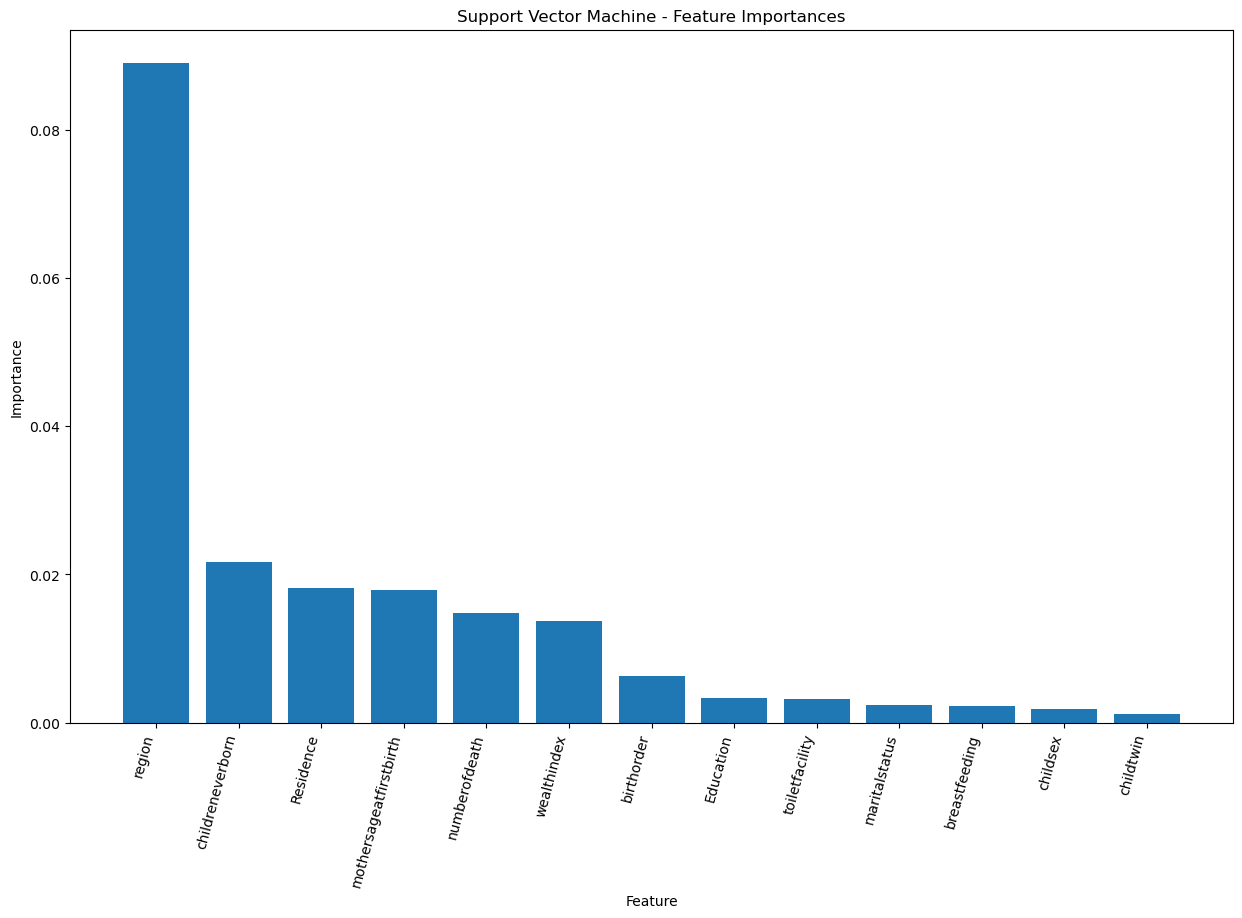

In [25]:
# e. Support Vector Machine (using permutation importance)
Svm_model = SVC(probability=True)
# TRAIN THE model 
Svm_model.fit(x_train, y_train)

# extracting the key factors
sv_result = permutation_importance(Svm_model, x_train, y_train, n_repeats=5, random_state=42)
importance_sv = sv_result.importances_mean
# put extracted key factors in a table 
importance_sv = pd.DataFrame({'Feature': x.columns, 'Importance': importance_sv})

# Sort by importance and visualize (optional)
importance_sv = importance_sv.sort_values(by='Importance', ascending=False)
print(importance_sv.head(10).to_markdown(index=False, numalign="left", stralign="left"))

# Make predictions on the test set
y_pred = Svm_model.predict(x_test)

# 1. Predict Probabilities
y_proba = Svm_model.predict_proba(x_test)[:, 1] # Probabilities for the positive class

# Calculate and print evaluation metrics
accuracy_sv = accuracy_score(y_test, y_pred)
precision_sv = precision_score(y_test, y_pred, average='weighted')
recall_sv = recall_score(y_test, y_pred, average='weighted')
f1_sv = f1_score(y_test, y_pred, average='weighted')
auc_sv = roc_auc_score(y_test, y_proba)

print("Support Vector Machine")
print(f"Accuracy: {accuracy_sv:.4f}")
print(f"Precision: {precision_sv:.4f}")
print(f"Recall: {recall_sv:.4f}")
print(f"F1-Score: {f1_sv:.4f}")
print(f"ROC AUC: {auc_sv:.4f}")

# Plotting feature importances
plt.figure(figsize=(15, 9)) # Adjust the size as needed
plt.bar(importance_sv['Feature'], importance_sv['Importance'])
plt.title("Support Vector Machine - Feature Importances")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=75, ha="right") # Rotate x-axis labels for readability
plt.show() # Display the plot

                   Feature  Importance
1   mothersageatfirstbirth    0.282085
5                   region    0.203933
10        childreneverborn    0.131171
7              wealthindex    0.130960
0            numberofdeath    0.094265
6                Residence    0.069939
11           breastfeeding    0.029504
8                Education    0.029255
9           toiletfacility    0.015207
12           maritalstatus    0.010690
2               birthorder    0.002545
4                childtwin    0.000447
3                 childsex    0.000000
Gradient Boosting
Accuracy: 0.5947
Precision: 0.5977
Recall: 0.5947
F1-Score: 0.5863
ROC AUC: 0.8099


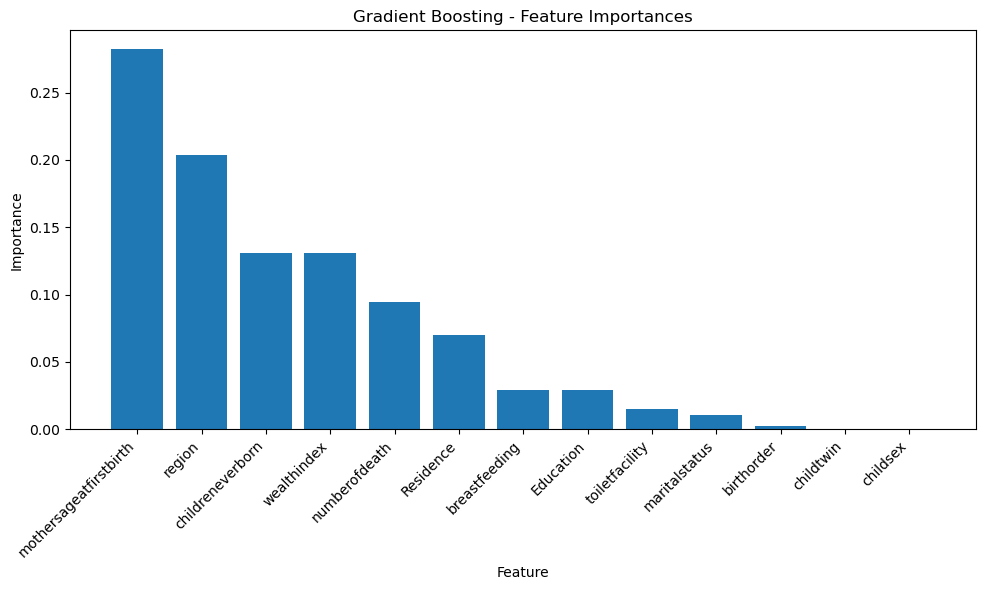

In [26]:
# 3. Build Gradient Boosting model
Gb_model = GradientBoostingClassifier(n_estimators=100, 
                                     learning_rate=0.1, random_state=42)
# You can adjust hyperparameters like n_estimators, learning_rate, max_depth

# 4. Train the model
Gb_model.fit(x_train, y_train)

# 8. Feature importance
importance_gb = Gb_model.feature_importances_

# Create a DataFrame for better visualization and sorting
feature_names = x_train.columns  # Assuming x_train is a pandas DataFrame
importance_Gb = pd.DataFrame({'Feature': feature_names, 'Importance': importance_gb})

# Sort by importance
importance_Gb = importance_Gb.sort_values(by='Importance', ascending=False)

# Print feature importances
print(importance_Gb)


# 5. Get training and testing accuracy
train_accuracy = Gb_model.score(x_train, y_train)
test_accuracy = Gb_model.score(x_test, y_test)

y_proba = Gb_model.predict_proba(x_test)[:, 1] # Probabilities for the positive class

# Calculate and print evaluation metrics
accuracy_Gb = accuracy_score(y_test, y_pred)
precision_Gb = precision_score(y_test, y_pred, average='weighted')
recall_Gb = recall_score(y_test, y_pred, average='weighted')
f1_Gb = f1_score(y_test, y_pred, average='weighted')
auc_Gb = roc_auc_score(y_test, y_proba)

print("Gradient Boosting")
print(f"Accuracy: {accuracy_Gb:.4f}")
print(f"Precision: {precision_Gb:.4f}")
print(f"Recall: {recall_Gb:.4f}")
print(f"F1-Score: {f1_Gb:.4f}")
print(f"ROC AUC: {auc_Gb:.4f}")

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.bar(importance_Gb['Feature'], importance_Gb['Importance'])
plt.title("Gradient Boosting - Feature Importances")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

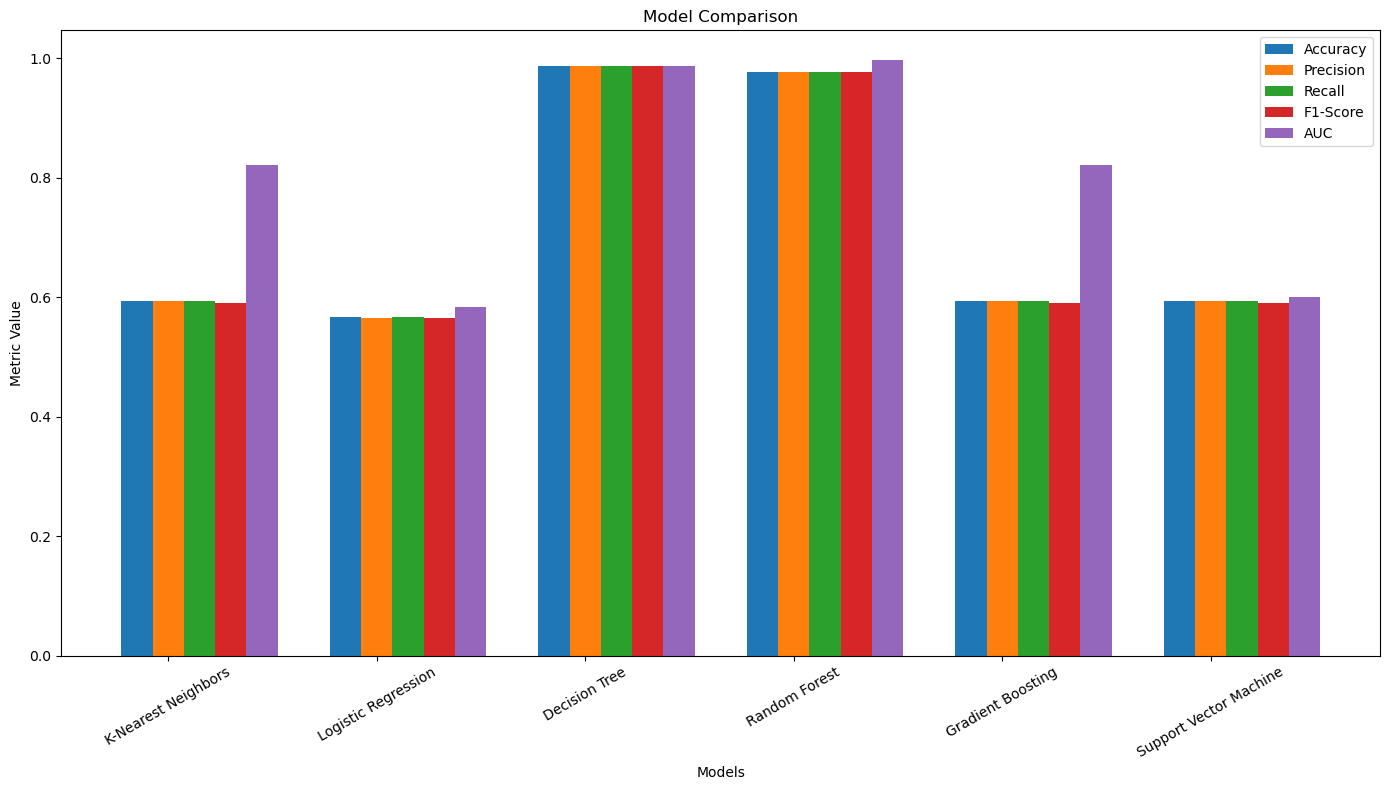

In [14]:
# Plotting the metrics
# Calculate and print evaluation metrics
accuracy_knn = accuracy_score(y_test, y_pred)
precision_knn = precision_score(y_test, y_pred, average='weighted')
recall_knn = recall_score(y_test, y_pred, average='weighted')
f1_knn = f1_score(y_test, y_pred, average='weighted')
auc_knn = roc_auc_score(y_test, y_proba)

accuracies = [accuracy_knn, accuracy_lr, accuracy_dt, accuracy_rf, accuracy_Gb, accuracy_sv]
precisions = [precision_knn, precision_lr, precision_dt, precision_rf, precision_Gb, precision_sv]
recalls = [recall_knn, recall_lr, recall_dt, recall_rf, recall_Gb, recall_sv]
aucs = [auc_knn, auc_lr, auc_dt, auc_rf, auc_Gb, auc_sv]
f1_scores = [f1_knn, f1_lr, f1_dt, f1_rf, f1_Gb, f1_sv]

metrics = [accuracies, precisions, recalls, f1_scores, aucs]
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
model_names = ['K-Nearest Neighbors', 'Logistic Regression', 'Decision Tree', 'Random Forest', 
               'Gradient Boosting', 'Support Vector Machine']

num_models = len(model_names)
num_metrics = len(metric_names)

bar_width = 0.15
index = np.arange(num_models)

plt.figure(figsize=(14, 8))

for i in range(num_metrics):
    plt.bar(index + i * bar_width, metrics[i], width=bar_width, label=metric_names[i])

plt.xlabel('Models')
plt.ylabel('Metric Value')
plt.title('Model Comparison')
plt.xticks(index + bar_width, model_names, rotation=30)
plt.legend()

plt.tight_layout()
plt.show()
